In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow.keras.backend as K
from tensorflow.keras import (
    layers,
    models,
    callbacks,
    utils,
    metrics,
    losses,
    optimizers,
)
import pandas as pd
import os

In [3]:
IMAGE_SIZE = 512
CHANNELS = 1
BATCH_SIZE = 32
NUM_FEATURES = 20
Z_DIM = 64
LEARNING_RATE = 0.0005
EPOCHS = 200
BETA = 2000
NUM_CONDITIONS = 4  # pore, graphite, silicone, CBD percentages

In [4]:
# Load attributes CSV
attributes = pd.read_csv(r"C:\Users\E2021593.CEET\Desktop\Mullers Code 3\area_pore_graphite_silicone_cbd2.csv")
labels = attributes[['Pore Percentage', 'Graphite Percentage', 
                    'Silicone Percentage', 'CBD Percentage']].values

# Create file paths
image_dir = r"C:\Users\E2021593.CEET\Desktop\Modified Mullers Images"
file_paths = [os.path.join(image_dir, fname) for fname in attributes['Image Name']]

# Create TensorFlow Dataset
def load_image(file_path, label):
    img = tf.io.read_file(file_path)
    img = tf.image.decode_png(img, channels=1)
    img = tf.image.resize(img, [IMAGE_SIZE, IMAGE_SIZE])
    img = tf.cast(img, "float32") / 255.0  # Preprocessing
    return img, label

dataset = tf.data.Dataset.from_tensor_slices((file_paths, labels))
train_data = dataset.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
train_data = train_data.shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

In [5]:
import matplotlib.pyplot as plt

def display(images, conditions=None, n=10, size=(20, 3), cmap="gray", as_type="float32", save_to=None):
    
    if images.max() > 1.0:
        images = images / 255.0
    elif images.min() < 0.0:
        images = (images + 1.0) / 2.0

    plt.figure(figsize=size)
    n = min(n, images.shape[0])
    for i in range(n):
        ax = plt.subplot(1, n, i + 1)
        plt.imshow(images[i].astype(as_type), cmap=cmap)
        plt.axis("off")
        if conditions is not None:
            # Format the condition vector (e.g., [0.65, 0.20, 0.10, 0.05]) into a string.
            cond_str = ', '.join(f'{val:.2f}' for val in conditions[i])
            ax.set_title(cond_str, fontsize=8)
    if save_to:
        plt.savefig(save_to)
        print(f"\nSaved to {save_to}")
    plt.show()

In [6]:
def sample_batch(dataset):
    # Take one batch from the dataset
    batch = dataset.take(1).get_single_element()
    # Each batch is a tuple(images, conditions)
    images, conditions = batch
    return images.numpy(), conditions.numpy()

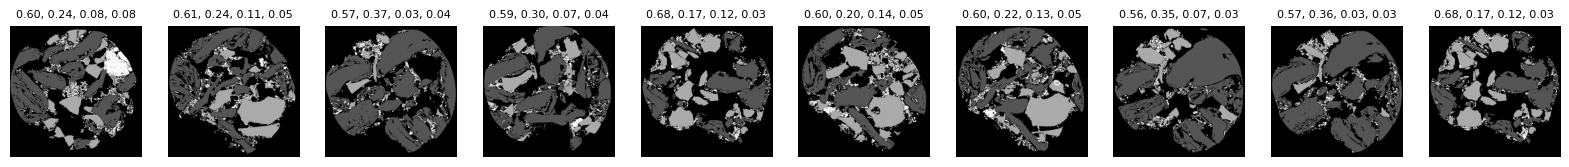

In [7]:
# Sample a batch from the training dataset (which now contains (image, condition) pairs)
images, conditions = sample_batch(train_data)

# Display the first 10 images with their condition vectors as titles.
display(images, conditions, n=10, size=(20, 3), cmap='gray')


In [8]:
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = K.random_normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon


In [9]:
encoder_img_input = layers.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, CHANNELS), name="encoder_img")
encoder_cond_input = layers.Input(shape=(NUM_CONDITIONS,), name="encoder_cond")

#Block 1
x = layers.Conv2D(NUM_FEATURES, 3, strides=2, padding="same")(encoder_img_input)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)

#Block 2
x = layers.Conv2D(NUM_FEATURES, 3, strides=2, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)

#Block 3
x = layers.Conv2D(NUM_FEATURES*2, 3, strides=2, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)

#Block 4
x = layers.Conv2D(NUM_FEATURES*2, 3, strides=2, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)

#Block 5
x = layers.Conv2D(NUM_FEATURES*4, 3, strides=2, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)

#Block 6
x = layers.Conv2D(NUM_FEATURES*4, 3, strides=2, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)

#Block 7
x = layers.Conv2D(NUM_FEATURES*8, 3, strides=2, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)

#Block 8
x = layers.Conv2D(NUM_FEATURES*8, 3, strides=2, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)

# Capture shape before flattening
shape_before_flattening = K.int_shape(x)[1:] 
print("Shape before flattening:", shape_before_flattening)  

# Condition processing
cond_dense = layers.Dense(64, activation='relu')(encoder_cond_input)
flat = layers.Flatten()(x)
combined = layers.concatenate([flat, cond_dense])

# Latent space
z_mean = layers.Dense(Z_DIM, name="z_mean")(combined)
z_log_var = layers.Dense(Z_DIM, name="z_log_var")(combined)
z = Sampling()([z_mean, z_log_var])

encoder = models.Model(
    inputs=[encoder_img_input, encoder_cond_input],
    outputs=[z_mean, z_log_var, z],
    name="encoder"
)
encoder.summary()

Shape before flattening: (2, 2, 160)



Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ encoder_img (InputLayer)      │ (None, 512, 512, 1)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d (Conv2D)               │ (None, 256, 256, 20)      │             200 │ encoder_img[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization           │ (None, 256, 256, 20)      │              80 │ conv2d[0][0]               │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ leaky_re_lu (LeakyReLU)       │ (None, 256, 256, 20)      │               0 │ batch_normalization[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_1 (Conv2D)             │ (None, 128, 128, 20)      │           3,620 │ leaky_re_lu[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_1         │ (None, 128, 128, 20)      │              80 │ conv2d_1[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ leaky_re_lu_1 (LeakyReLU)     │ (None, 128, 128, 20)      │               0 │ batch_normalization_1[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_2 (Conv2D)             │ (None, 64, 64, 40)        │           7,240 │ leaky_re_lu_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_2         │ (None, 64, 64, 40)        │             160 │ conv2d_2[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ leaky_re_lu_2 (LeakyReLU)     │ (None, 64, 64, 40)        │               0 │ batch_normalization_2[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_3 (Conv2D)             │ (None, 32, 32, 40)        │          14,440 │ leaky_re_lu_2[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_3         │ (None, 32, 32, 40)        │             160 │ conv2d_3[0][0]             │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ leaky_re_lu_3 (LeakyReLU)     │ (None, 32, 32, 40)        │               0 │ batch_normalization_3[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_4 (Conv2D)             │ (None, 16, 16, 80)        │          28,880 │ leaky_re_lu_3[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_4         │ (None, 16, 16, 80)        │             320 │ conv2d_4[0][0]             │
│ (BatchNormalization)          │                           │               

 Total params: 550,940 (2.10 MB)

 Trainable params: 549,740 (2.10 MB)

 Non-trainable params: 1,200 (4.69 KB)

In [10]:
decoder_z_input = layers.Input(shape=(Z_DIM,), name="decoder_z")
decoder_cond_input = layers.Input(shape=(NUM_CONDITIONS,), name="decoder_cond")

# Process condition
cond_dense = layers.Dense(64, activation='relu')(decoder_cond_input)
combined = layers.concatenate([decoder_z_input, cond_dense])

# Use the captured shape
x = layers.Dense(np.prod(shape_before_flattening))(combined)
x = layers.Reshape(shape_before_flattening)(x)  # Now using pre-calculated shape


# Upconvolutional blocks
#Block 1
x = layers.Conv2DTranspose(NUM_FEATURES*8, 3, strides=2, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)

#Block 2
x = layers.Conv2DTranspose(NUM_FEATURES*8, 3, strides=2, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)

#Block 3
x = layers.Conv2DTranspose(NUM_FEATURES*4, 3, strides=2, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)

#Block 4
x = layers.Conv2DTranspose(NUM_FEATURES*4, 3, strides=2, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)

#Block 5
x = layers.Conv2DTranspose(NUM_FEATURES*2, 3, strides=2, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)

#Block 6
x = layers.Conv2DTranspose(NUM_FEATURES*2, 3, strides=2, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)

#Block 7
x = layers.Conv2DTranspose(NUM_FEATURES, 3, strides=2, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)

#Block 8
x = layers.Conv2DTranspose(NUM_FEATURES, 3, strides=2, padding="same")(x)
x = layers.BatchNormalization()(x)
x = layers.LeakyReLU()(x)


decoder_output = layers.Conv2DTranspose(
    CHANNELS, 3, padding="same", activation="sigmoid")(x)

decoder = models.Model(
    inputs=[decoder_z_input, decoder_cond_input],
    outputs=decoder_output,
    name="decoder"
)

decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ decoder_cond (InputLayer)     │ (None, 4)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ decoder_z (InputLayer)        │ (None, 64)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 64)                │             320 │ decoder_cond[0][0]         │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate_1 (Concatenate)   │ (None, 128)               │               0 │ decoder_z[0][0],           │
│                               │                           │                 │ dense_1[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_2 (Dense)               │ (None, 640)               │          82,560 │ concatenate_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ reshape (Reshape)             │ (None, 2, 2, 160)         │               0 │ dense_2[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_transpose              │ (None, 4, 4, 160)         │         230,560 │ reshape[0][0]              │
│ (Conv2DTranspose)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_8         │ (None, 4, 4, 160)         │             640 │ conv2d_transpose[0][0]     │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ leaky_re_lu_8 (LeakyReLU)     │ (None, 4, 4, 160)         │               0 │ batch_normalization_8[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_transpose_1            │ (None, 8, 8, 160)         │         230,560 │ leaky_re_lu_8[0][0]        │
│ (Conv2DTranspose)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_9         │ (None, 8, 8, 160)         │             640 │ conv2d_transpose_1[0][0]   │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ leaky_re_lu_9 (LeakyReLU)     │ (None, 8, 8, 160)         │               0 │ batch_normalization_9[0][… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_transpose_2            │ (None, 16, 16, 80)        │         115,280 │ leaky_re_lu_9[0][0]        │
│ (Conv2DTranspose)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ batch_normalization_10        │ (None, 16, 16, 80)        │             320 │ conv2d_transpose_2[0][0]   │
│ (BatchNormalization)          │                           │               

 Total params: 773,661 (2.95 MB)

 Trainable params: 772,461 (2.95 MB)

 Non-trainable params: 1,200 (4.69 KB)

In [11]:
class CVAE(models.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = metrics.Mean(name="reconstruction_loss")
        self.kl_loss_tracker = metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def call(self, inputs):
        img, cond = inputs
        z_mean, z_log_var, z = self.encoder([img, cond])
        reconstruction = self.decoder([z, cond])
        return z_mean, z_log_var, reconstruction

    def train_step(self, data):
        img, cond = data
        
        with tf.GradientTape() as tape:
            # Forward pass
            z_mean, z_log_var, reconstruction = self([img, cond], training=True)
            
            # Manual MSE calculation
            pixel_wise_error = img - reconstruction
            squared_error = tf.square(pixel_wise_error)
            reconstruction_loss = tf.reduce_mean(BETA * squared_error)
            
            # KL Divergence calculation
            kl_loss = -0.5 * tf.reduce_sum(
                1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var),
                axis=1
            )
            kl_loss = tf.reduce_mean(kl_loss)
            
            # Total loss
            total_loss = reconstruction_loss + kl_loss

        # Backpropagation
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        # Update metrics
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)

        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

In [12]:
cvae = CVAE(encoder, decoder)
optimizer = optimizers.Adam(learning_rate=LEARNING_RATE)
cvae.compile(optimizer=optimizer)

In [13]:
# Callbacks
model_checkpoint_callback = callbacks.ModelCheckpoint(
    filepath="./cvae_checkpoint.keras",
    save_weights_only=False,
    save_freq="epoch",
    monitor="loss",
    mode="min",
    save_best_only=True,
    verbose=0,
)


In [14]:
history = cvae.fit(
    train_data,
    epochs=EPOCHS,
    callbacks=[model_checkpoint_callback]
)

Epoch 1/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 86s 3s/step - kl_loss: 0.8700 - loss: 300.2883 - reconstruction_loss: 299.4184
Epoch 2/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 76s 3s/step - kl_loss: 0.0660 - loss: 128.9404 - reconstruction_loss: 128.8743
Epoch 3/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 105s 4s/step - kl_loss: 2.8358 - loss: 109.2897 - reconstruction_loss: 106.4540
Epoch 4/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 148s 5s/step - kl_loss: 2.3416 - loss: 77.5286 - reconstruction_loss: 75.1869
Epoch 5/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 145s 5s/step - kl_loss: 1.1664 - loss: 69.6515 - reconstruction_loss: 68.4851
Epoch 6/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 146s 5s/step - kl_loss: 0.6085 - loss: 67.3735 - reconstruction_loss: 66.7650
Epoch 7/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 145s 5s/step - kl_loss: 0.1639 - loss: 65.6860 - reconstruction_loss: 65.5222
Epoch 8/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 147s 5s/step - kl_loss: 0.0301 - loss: 64.7365 - reconstruction_loss: 64.7064
Epoch 9/200
29/29 ━━━━━━━━━━━━━━━━━━━━ 202s 5s/step - kl_los

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Original Images


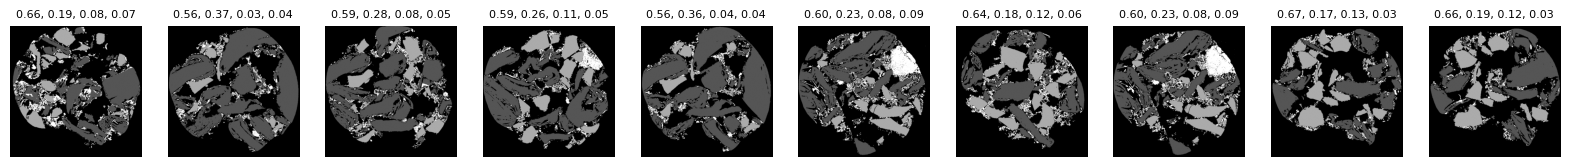

Reconstructions


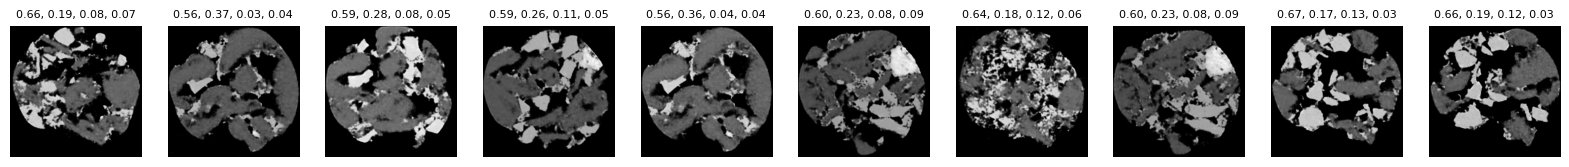

In [16]:
for example_batch in train_data.take(1):
    example_images, example_conditions = example_batch
    break  # We only need one batch

# Convert to numpy arrays 
example_images_np = example_images.numpy()
example_conditions_np = example_conditions.numpy()

# Get Reconstructions
z_mean, z_log_var, reconstructions = cvae.predict([example_images_np, example_conditions_np])

# Display Original Images and Their Reconstructions
print("Original Images")
display(example_images_np, conditions=example_conditions_np, n=10, size=(20, 3))
print("Reconstructions")
display(reconstructions, conditions=example_conditions_np, n=10, size=(20, 3))


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 577ms/step


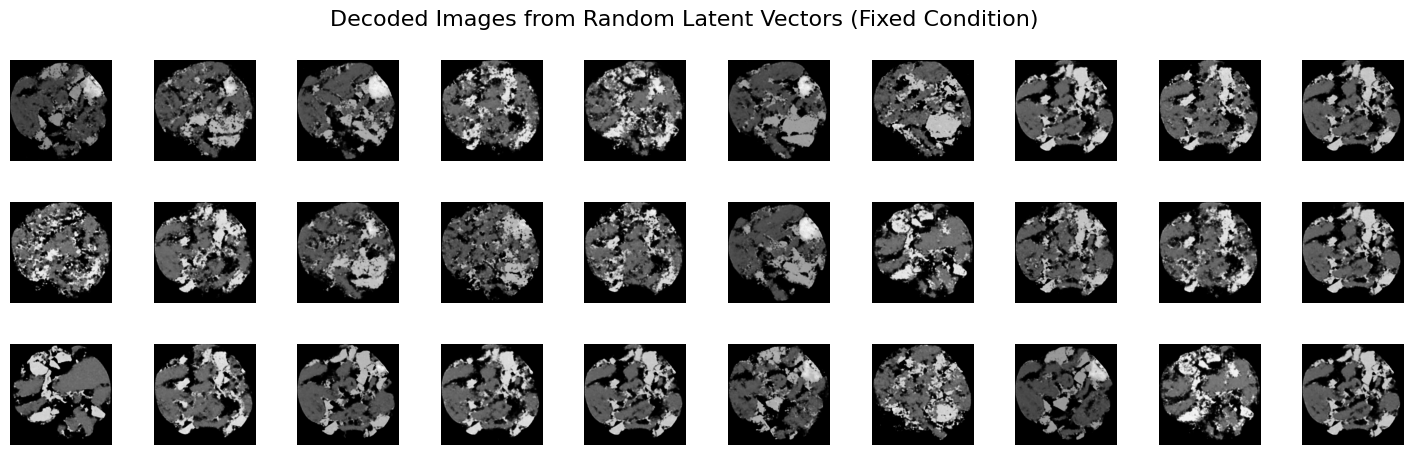

In [21]:
import numpy as np
import matplotlib.pyplot as plt

# Define the Grid Size
grid_width, grid_height = (10, 3)
num_samples = grid_width * grid_height

# Sample Latent Vectors from the Standard Normal Distribution
z_sample = np.random.normal(size=(num_samples, Z_DIM))

# Define a Fixed Condition for All Samples
# For example, here we assume the condition is a normalized vector for [Pore, Graphite, Silicone, CBD]
fixed_condition = np.array([[0.60, 0.25, 0.10, 0.05]])
# Replicate the condition for all samples:
condition_vector = np.tile(fixed_condition, (num_samples, 1))

# Decode the Sampled Points
reconstructions = decoder.predict([z_sample, condition_vector])

# Plot the Generated Images in a Grid
fig = plt.figure(figsize=(18, 5))
fig.subplots_adjust(hspace=0.4, wspace=0.4)
for i in range(num_samples):
    ax = fig.add_subplot(grid_height, grid_width, i + 1)
    ax.axis("off")
    ax.imshow(reconstructions[i].squeeze(), cmap="gray")
plt.suptitle("Decoded Images from Random Latent Vectors (Fixed Condition)", fontsize=16)
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 480ms/step


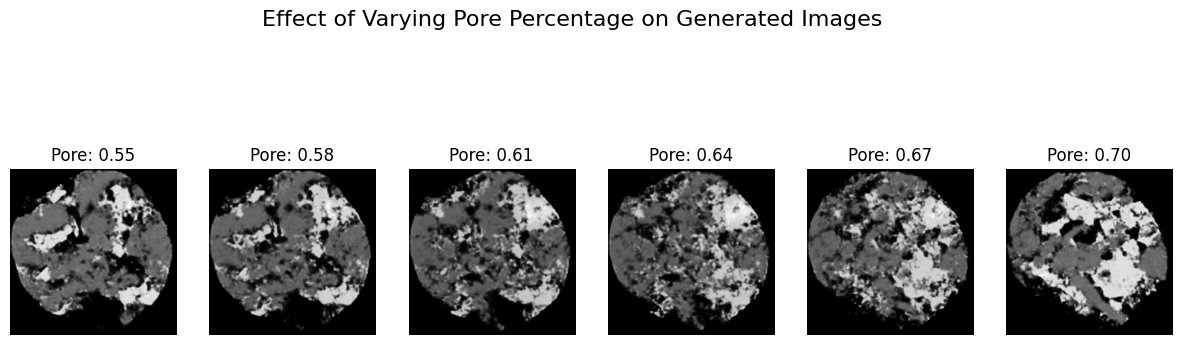

In [22]:
num_variations = 6  # Number of different conditions to test

# Sample a Fixed Latent Vector
z_fixed = np.random.normal(size=(1, Z_DIM))

# Define Base Condition
# Choose an initial condition from within the observed limits
base_condition = np.array([[0.55, 0.30, 0.10, 0.05]])  # Pore, Graphite, Silicone, CBD

#Generate Variations of Condition (Modify Pore Percentage)
condition_variations = []
pore_values = np.linspace(0.55, 0.70, num_variations)  # Vary pore percentage from 55% to 70%

for pore in pore_values:
    # Adjust the other components proportionally to maintain sum = 1
    remaining = 1 - pore
    graphite = remaining * (0.30 / (0.30 + 0.10 + 0.05))  # Adjust proportionally
    silicone = remaining * (0.10 / (0.30 + 0.10 + 0.05))
    cbd = remaining * (0.05 / (0.30 + 0.10 + 0.05))

    condition_variations.append([pore, graphite, silicone, cbd])

# Convert to NumPy array
condition_variations = np.array(condition_variations)

# Decode the Sampled Points
reconstructions = decoder.predict([np.tile(z_fixed, (num_variations, 1)), condition_variations])

# Plot the Generated Images in a Row
fig, axes = plt.subplots(1, num_variations, figsize=(15, 5))
for i in range(num_variations):
    axes[i].imshow(reconstructions[i].squeeze(), cmap="gray")
    axes[i].axis("off")
    axes[i].set_title(f"Pore: {condition_variations[i, 0]:.2f}")

plt.suptitle("Effect of Varying Pore Percentage on Generated Images", fontsize=16)
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


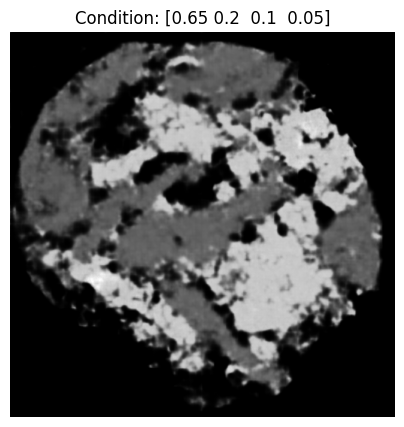

In [32]:
def generate_microstructure(condition, decoder):
    latent_sample = tf.random.normal(shape=(1, Z_DIM))  # Sample from latent space
    generated_img = decoder.predict([latent_sample, condition])
    return generated_img[0]

# Example condition [pore%, graphite%, silicone%, CBD%] normalized to 0-1
target_condition = np.array([[0.65, 0.20, 0.10, 0.05]])  # 65% pores, 20% graphite, etc.
generated_image = generate_microstructure(target_condition, decoder)

# Display with matplotlib
plt.figure(figsize=(5, 5))
plt.imshow(generated_image.squeeze(), cmap='gray')  # Remove channel dimension with squeeze()
plt.title(f'Condition: {target_condition[0]}')
plt.axis('off')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step


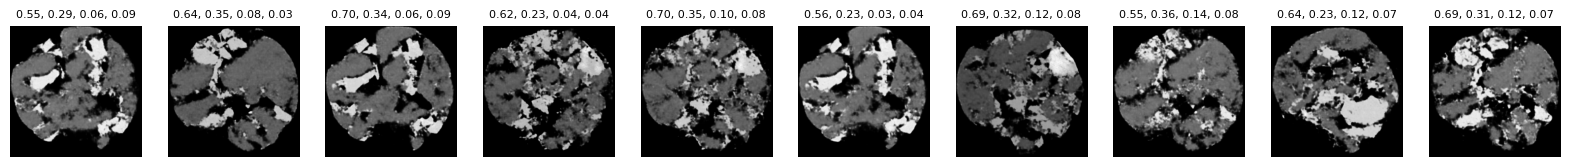

In [31]:
# Generate a batch of microstructures with controlled compositions
conditions = np.random.uniform(low=[0.5456, 0.1628, 0.0262, 0.028],  # Min percentages
                               high=[0.7008, 0.3734, 0.1466, 0.0923], # Max percentages
                               size=(10, 4))  # 10 samples
latent_vectors = tf.random.normal(shape=(10, Z_DIM))
generated = decoder.predict([latent_vectors, conditions])

# Visualize
display(generated, conditions, n=10, cmap='gray')

In [33]:
def interpolate_conditions(cond1, cond2, decoder, steps=10):
    interpolated = []
    for alpha in np.linspace(0, 1, steps):
        latent = tf.random.normal(shape=(1, Z_DIM))
        interp_cond = alpha * cond1 + (1 - alpha) * cond2
        img = decoder.predict([latent, interp_cond])[0]
        interpolated.append(img)
    return interpolated

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step


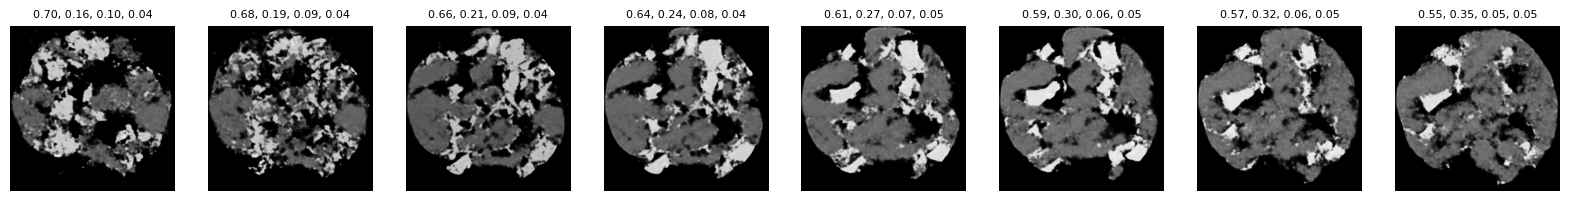

In [36]:
def interpolate_conditions(cond1, cond2, decoder, steps=10):
    interpolated_images = []
    interpolated_conditions = []
    latent = tf.random.normal(shape=(1, Z_DIM))  # Single latent vector
    
    for alpha in np.linspace(0, 1, steps):
        # Calculate interpolated condition
        interp_cond = alpha * cond1 + (1 - alpha) * cond2
        # Generate image
        img = decoder.predict([latent, interp_cond])[0]
        # Store results
        interpolated_images.append(img)
        interpolated_conditions.append(interp_cond.squeeze())  # Remove batch dimension
    
    return interpolated_images, interpolated_conditions

# Example usage
cond1 = np.array([[0.55, 0.35, 0.05, 0.05]])  # Start condition (55% pore, 35% graphite)
cond2 = np.array([[0.70, 0.16, 0.10, 0.04]])  # End condition (70% pore, 16% graphite)

images, conditions = interpolate_conditions(cond1, cond2, decoder, steps=8)

# Display with conditions using your existing display function
display(np.array(images), 
        conditions=conditions,
        n=8, 
        size=(20, 3),
        cmap='gray')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


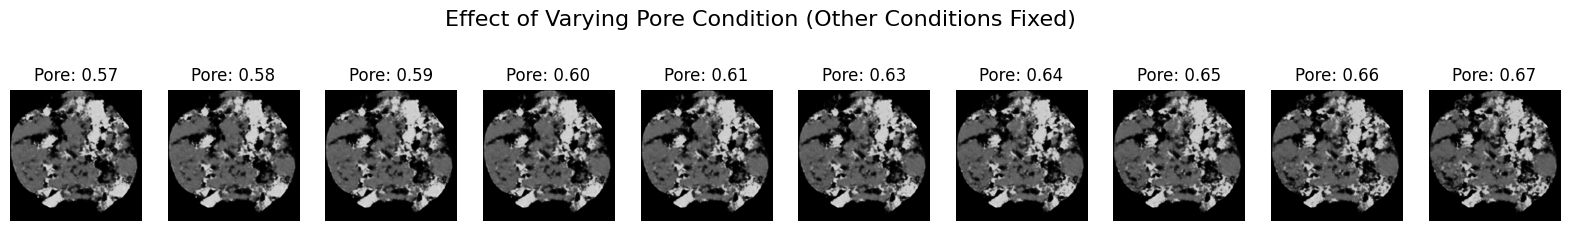

In [37]:
import numpy as np
import matplotlib.pyplot as plt

# Define Pore Values to Vary (Keeping Other Conditions Constant)
pore_values = np.linspace(0.57, 0.67, num=10)  # 10 steps from 0.57 to 0.67

# Define Constant Values for Other Conditions
graphite, silicone, cbd = 0.25, 0.10, 0.05  # Fixed values

# Sample a Fixed Latent Vector
z_sample = np.random.normal(size=(1, Z_DIM))  # Single latent vector for all conditions

# Generate Images for Different Pore Values
generated_images = []
for pore in pore_values:
    condition = np.array([[pore, graphite, silicone, cbd]])  # Changing only Pore
    decoded_image = decoder.predict([z_sample, condition])[0]  # Decode using fixed z
    generated_images.append(decoded_image)

# Plot the Generated Images
fig, axes = plt.subplots(1, 10, figsize=(20, 3))
for i, ax in enumerate(axes):
    ax.imshow(generated_images[i].squeeze(), cmap="gray")
    ax.set_title(f"Pore: {pore_values[i]:.2f}")
    ax.axis("off")
plt.suptitle("Effect of Varying Pore Condition (Other Conditions Fixed)", fontsize=16)
plt.show()
